# Predicting County Health Outcomes
### 2018 County Health Rankings Dataset

**Name:** Gulnabat Mamedova  
**Course:** Introduction to Statistical Machine Learning

**Goal 1:** Predict the Years of Potential Life Lost (YPLL) Rate from socioeconomic, behavioral, and environmental features.  
**Goal 2:** Find out which features drive poor health outcomes the most.


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load the Dataset

In [2]:
df = pd.read_excel(
    r"C:\Users\gulnabat\Desktop\Introduction to statistical machine learning\2023380196_Gulnabat_Mamedova\2018 County Health Rankings Data.xlsx",
    sheet_name='Ranked Measure Data',
    engine='openpyxl',
    header=1
)

print("Shape:", df.shape)
df.head(3)

Shape: (3143, 165)


,FIPS,State,County,Years of Potential Life Lost Rate,95% CI - Low,95% CI - High,Quartile,Years of Potential Life Lost Rate (Black),Years of Potential Life Lost Rate (Hispanic),Years of Potential Life Lost Rate (White),...,95% CI - High.20,Quartile.33,% Drive Alone (Black),% Drive Alone (Hispanic),% Drive Alone (White),# Workers who Drive Alone,% Long Commute - Drives Alone,95% CI - Low.21,95% CI - High.21,Quartile.34
0,1001.0,Alabama,Autauga,9409.294766,8492.111635,10326.477898,2,11806.223285,NaN,9148.381743,...,88.431482,4,82.494851,NaN,82.539683,21082.0,40.8,36.698437,44.901563,3
1,1003.0,Alabama,Baldwin,7467.596664,7025.900408,7909.292920,1,10335.702691,2827.348216,7484.117065,...,86.017804,2,85.567010,68.8648,84.646255,73058.0,40.1,37.614952,42.585048,3
2,1005.0,Alabama,Barbour,8929.474982,7633.929691,10225.020273,1,9141.333085,NaN,8896.000532,...,85.796041,1,80.341227,NaN,85.656228,7271.0,35.1,29.740946,40.459054,2


## 3. Select Features and Target

In [3]:
TARGET = 'Years of Potential Life Lost Rate'

FEATURES = [
    '% Children in Poverty',
    'Income Ratio',
    'Graduation Rate',
    '% Unemployed',
    '% Single-Parent Households',
    '% Uninsured',
    'PCP Rate',
    '% Smokers',
    '% Obese',
    '% Physically Inactive',
    '% Excessive Drinking',
    'Food Environment Index',
    'Average Daily PM2.5',
    'Violent Crime Rate',
]

df_work = df[[TARGET] + FEATURES].copy()

print("Missing values per column:")
print(df_work.isnull().sum())

Missing values per column:
Years of Potential Life Lost Rate    182
% Children in Poverty                  2
Income Ratio                           3
Graduation Rate                      471
% Unemployed                           2
% Single-Parent Households             2
% Uninsured                            2
PCP Rate                             135
% Smokers                              1
% Obese                                1
% Physically Inactive                  1
% Excessive Drinking                   1
Food Environment Index                20
Average Daily PM2.5                   35
Violent Crime Rate                   177
dtype: int64


## 4. Preprocessing

In [4]:
# Drop rows with missing target
df_work = df_work.dropna(subset=[TARGET])
print(f"Counties after dropping missing target: {len(df_work)}")

# Separate features and target
X = df_work[FEATURES]
y = df_work[TARGET]

# Fill missing feature values with the column median
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=FEATURES)

# Train / test split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Reset indices so statsmodels can align them with the feature DataFrames
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)
print(f"Training set: {len(X_train)} counties")
print(f"Test set:     {len(X_test)} counties")

# Standardise — fit on training set only, then apply to test
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print("Preprocessing done!")

# Keep feature names so OLS shows real column names instead of x1, x2...
X_train_sm = pd.DataFrame(X_train_s, columns=FEATURES)
X_test_sm  = pd.DataFrame(X_test_s,  columns=FEATURES)


Counties after dropping missing target: 2961
Training set: 2368 counties
Test set:     593 counties
Preprocessing done!


## 5. Exploratory Data Analysis

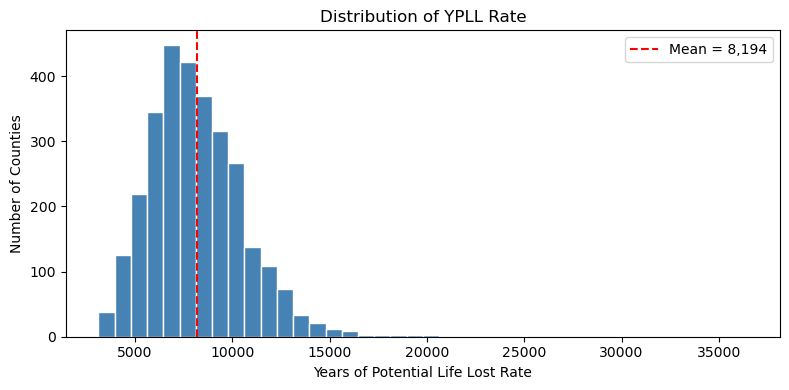

In [5]:
# Distribution of YPLL Rate
plt.figure(figsize=(8, 4))
plt.hist(y, bins=40, color='steelblue', edgecolor='white')
plt.axvline(y.mean(), color='red', linestyle='--', label=f'Mean = {y.mean():,.0f}')
plt.xlabel('Years of Potential Life Lost Rate')
plt.ylabel('Number of Counties')
plt.title('Distribution of YPLL Rate')
plt.legend()
plt.tight_layout()
plt.show()

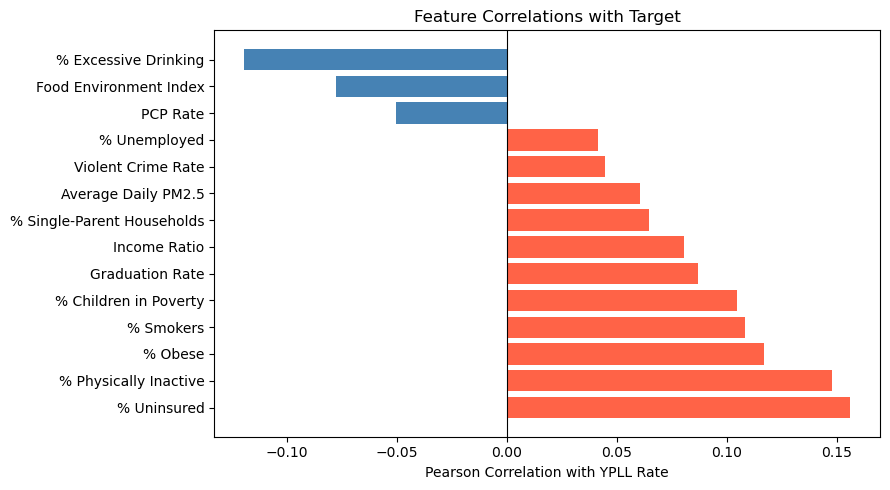

% Uninsured                   0.156
% Physically Inactive         0.148
% Obese                       0.117
% Smokers                     0.108
% Children in Poverty         0.105
Graduation Rate               0.087
Income Ratio                  0.080
% Single-Parent Households    0.064
Average Daily PM2.5           0.060
Violent Crime Rate            0.044
% Unemployed                  0.041
PCP Rate                     -0.050
Food Environment Index       -0.078
% Excessive Drinking         -0.119
dtype: float64


In [6]:
# Correlation of each feature with YPLL Rate
correlations = X.corrwith(y).sort_values(ascending=False)

colors = ['tomato' if c > 0 else 'steelblue' for c in correlations]
plt.figure(figsize=(9, 5))
plt.barh(correlations.index, correlations.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Pearson Correlation with YPLL Rate')
plt.title('Feature Correlations with Target')
plt.tight_layout()
plt.show()

print(correlations.round(3))

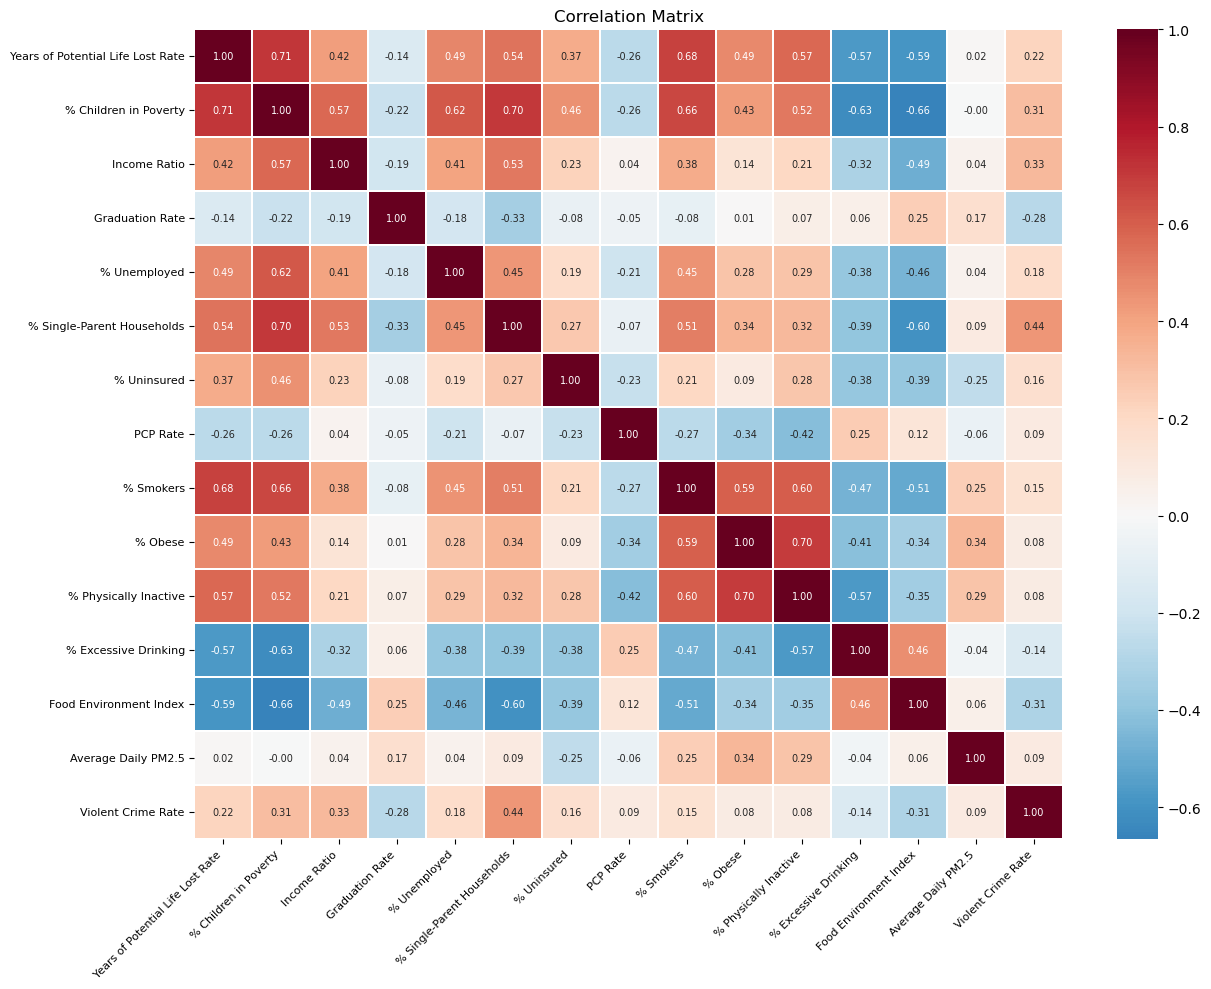

In [7]:
# Correlation heatmap — full matrix (no mask)
plt.figure(figsize=(13, 10))
corr_matrix = pd.concat([y.reset_index(drop=True),
                          X.reset_index(drop=True)], axis=1).corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.3,
            annot_kws={'size': 7})
plt.title('Correlation Matrix')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()


## 6. Linear Regression (OLS)

In [8]:
# Add intercept, fit model, predict
X_train_ols = sm.add_constant(X_train_sm)
X_test_ols  = sm.add_constant(X_test_sm)

ols_model  = sm.OLS(y_train, X_train_ols).fit()
y_pred_ols = ols_model.predict(X_test_ols)

ols_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ols))
ols_r2   = r2_score(y_test, y_pred_ols)

print(f"Test RMSE : {ols_rmse:,.1f}")
print(f"Test R²   : {ols_r2:.4f}")


Test RMSE : 1,474.5
Test R²   : 0.6306


In [9]:
# Full summary with coefficients, p-values, and confidence intervals
print(ols_model.summary())

                                    OLS Regression Results                                   
Dep. Variable:     Years of Potential Life Lost Rate   R-squared:                       0.643
Model:                                           OLS   Adj. R-squared:                  0.640
Method:                                Least Squares   F-statistic:                     302.2
Date:                               Fri, 08 May 2026   Prob (F-statistic):               0.00
Time:                                       14:20:32   Log-Likelihood:                -20753.
No. Observations:                               2368   AIC:                         4.154e+04
Df Residuals:                                   2353   BIC:                         4.162e+04
Df Model:                                         14                                         
Covariance Type:                           nonrobust                                         
                                 coef    std err          t 

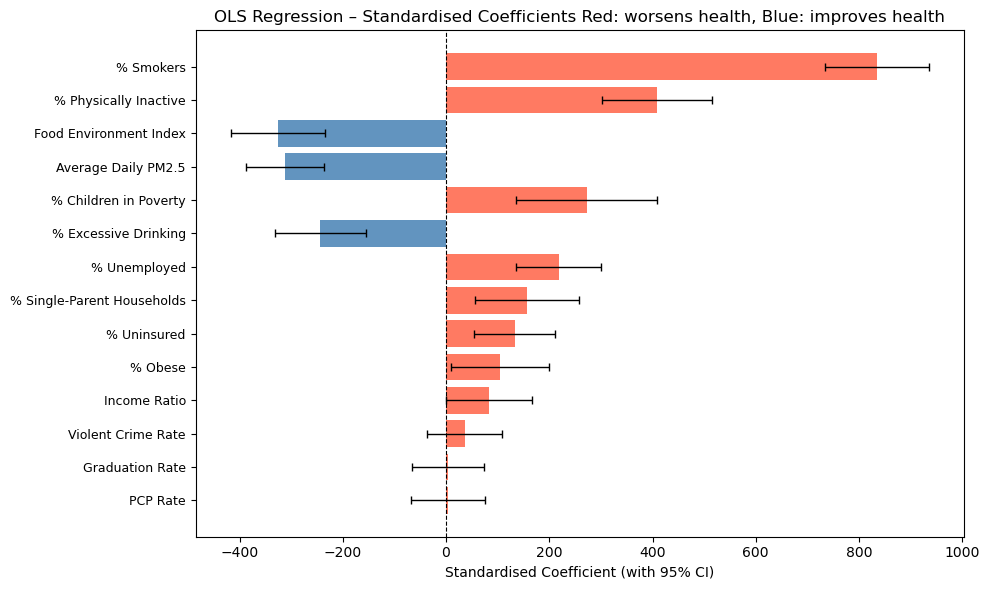

In [11]:
# Plot standardised coefficients with real feature names
coef  = ols_model.params[1:]
ci    = ols_model.conf_int().iloc[1:]
order = coef.abs().sort_values(ascending=True).index

colors_coef = ['tomato' if c > 0 else 'steelblue' for c in coef[order]]

plt.figure(figsize=(10, 6))
plt.barh(range(len(order)), coef[order], color=colors_coef, alpha=0.85)
plt.errorbar(coef[order], range(len(order)),
             xerr=[coef[order] - ci.loc[order, 0],
                   ci.loc[order, 1] - coef[order]],
             fmt='none', color='black', linewidth=1, capsize=3)
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.yticks(range(len(order)), order, fontsize=9)
plt.xlabel('Standardised Coefficient (with 95% CI)')
plt.title('OLS Regression – Standardised Coefficients Red: worsens health, Blue: improves health')
plt.tight_layout()
plt.show()


## 7. Cross-Validation

In [12]:
cv = KFold(n_splits=10, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    LinearRegression(),
    X_train_s, y_train,
    cv=cv,
    scoring='neg_mean_squared_error'
)

cv_rmse = np.sqrt(-cv_scores)

print("RMSE per fold:")
for i, r in enumerate(cv_rmse, 1):
    print(f"  Fold {i:2d}: {r:,.1f}")

print(f"Mean CV RMSE : {cv_rmse.mean():,.1f}")
print(f"Std  CV RMSE : {cv_rmse.std():,.1f}")

RMSE per fold:
  Fold  1: 1,270.6
  Fold  2: 1,228.0
  Fold  3: 1,434.2
  Fold  4: 1,507.0
  Fold  5: 1,743.7
  Fold  6: 1,529.6
  Fold  7: 1,837.4
  Fold  8: 1,381.7
  Fold  9: 2,121.7
  Fold 10: 1,534.5
Mean CV RMSE : 1,558.8
Std  CV RMSE : 259.3


## 8. Lasso and Ridge Regularisation

In [13]:
# Lasso — finds best alpha via cross-validation, can zero out features
lasso = LassoCV(cv=5, random_state=42, max_iter=3000)
lasso.fit(X_train_s, y_train)

y_pred_lasso = lasso.predict(X_test_s)
lasso_rmse   = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
lasso_r2     = r2_score(y_test, y_pred_lasso)

print("=== LASSO ===")
print(f"Best alpha : {lasso.alpha_:.2f}")
print(f"Test RMSE  : {lasso_rmse:,.1f}")
print(f"Test R²    : {lasso_r2:.4f}")

print("Coefficients (0 = feature removed by Lasso):")
for name, coef in zip(FEATURES, lasso.coef_):
    removed = '  <-- removed' if abs(coef) < 1e-6 else ''
    print(f"  {name:<35s} {coef:+.2f}{removed}")

=== LASSO ===
Best alpha : 7.89
Test RMSE  : 1,473.4
Test R²    : 0.6311
Coefficients (0 = feature removed by Lasso):
  % Children in Poverty               +285.84
  Income Ratio                        +78.26
  Graduation Rate                     -0.00  <-- removed
  % Unemployed                        +211.29
  % Single-Parent Households          +153.84
  % Uninsured                         +129.66
  PCP Rate                            -0.00  <-- removed
  % Smokers                           +829.63
  % Obese                             +96.74
  % Physically Inactive               +403.53
  % Excessive Drinking                -241.32
  Food Environment Index              -327.61
  Average Daily PM2.5                 -297.29
  Violent Crime Rate                  +29.29


In [14]:
# Ridge — shrinks all coefficients but keeps every feature
ridge = RidgeCV(alphas=np.logspace(-2, 4, 30), cv=5)
ridge.fit(X_train_s, y_train)

y_pred_ridge = ridge.predict(X_test_s)
ridge_rmse   = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_r2     = r2_score(y_test, y_pred_ridge)

print("=== RIDGE ===")
print(f"Best alpha : {ridge.alpha_:.2f}")
print(f"Test RMSE  : {ridge_rmse:,.1f}")
print(f"Test R²    : {ridge_r2:.4f}")

=== RIDGE ===
Best alpha : 137.38
Test RMSE  : 1,470.2
Test R²    : 0.6327


## 9. Random Forest

In [15]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train_s, y_train)

y_pred_rf = rf.predict(X_test_s)
rf_rmse   = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2     = r2_score(y_test, y_pred_rf)

print("=== RANDOM FOREST ===")
print(f"Test RMSE : {rf_rmse:,.1f}")
print(f"Test R²   : {rf_r2:.4f}")

=== RANDOM FOREST ===
Test RMSE : 1,348.4
Test R²   : 0.6911


## 10. Gradient Boosting

In [16]:
gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb.fit(X_train_s, y_train)

y_pred_gb = gb.predict(X_test_s)
gb_rmse   = np.sqrt(mean_squared_error(y_test, y_pred_gb))
gb_r2     = r2_score(y_test, y_pred_gb)

print("=== GRADIENT BOOSTING ===")
print(f"Test RMSE : {gb_rmse:,.1f}")
print(f"Test R²   : {gb_r2:.4f}")

=== GRADIENT BOOSTING ===
Test RMSE : 1,397.3
Test R²   : 0.6682


## 11. Model Comparison

In [17]:
results = pd.DataFrame({
    'Model'    : ['OLS', 'Ridge', 'Lasso', 'Random Forest', 'Gradient Boosting'],
    'Test RMSE': [ols_rmse, ridge_rmse, lasso_rmse, rf_rmse, gb_rmse],
    'Test R2'  : [ols_r2,   ridge_r2,   lasso_r2,  rf_r2,   gb_r2],
})
results = results.sort_values('Test RMSE').reset_index(drop=True)
print(results.round(4).to_string(index=False))
print(f"Best model: {results.iloc[0]['Model']}")

            Model  Test RMSE  Test R2
    Random Forest  1348.3893   0.6911
Gradient Boosting  1397.3051   0.6682
            Ridge  1470.2301   0.6327
            Lasso  1473.4017   0.6311
              OLS  1474.4645   0.6306
Best model: Random Forest


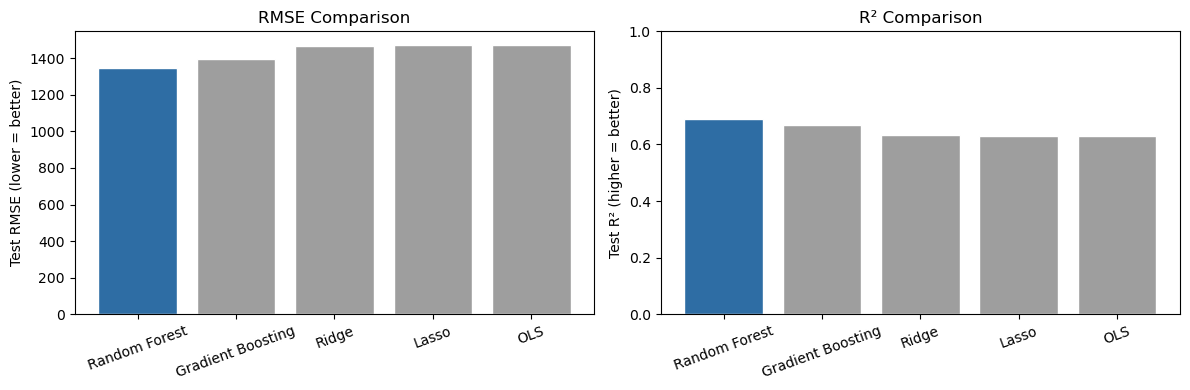

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#2E6DA4' if m == results.iloc[0]['Model'] else '#9E9E9E'
          for m in results['Model']]

ax1.bar(results['Model'], results['Test RMSE'], color=colors, edgecolor='white')
ax1.set_ylabel('Test RMSE (lower = better)')
ax1.set_title('RMSE Comparison')
ax1.tick_params(axis='x', rotation=20)

ax2.bar(results['Model'], results['Test R2'], color=colors, edgecolor='white')
ax2.set_ylabel('Test R² (higher = better)')
ax2.set_title('R² Comparison')
ax2.set_ylim(0, 1)
ax2.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 12. Diagnostic Plots — Best Model

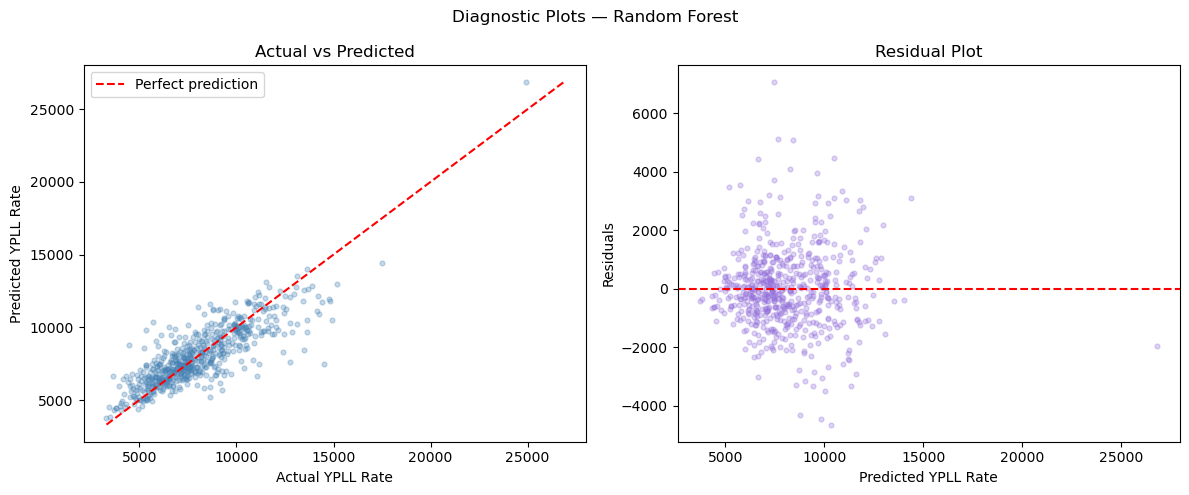

In [19]:
# Use whichever model had the lower RMSE
if rf_rmse <= gb_rmse:
    y_pred_best = y_pred_rf
    best_name   = 'Random Forest'
else:
    y_pred_best = y_pred_gb
    best_name   = 'Gradient Boosting'

residuals = y_test.values - y_pred_best

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f'Diagnostic Plots — {best_name}', fontsize=12)

# Actual vs Predicted
ax1.scatter(y_test, y_pred_best, alpha=0.3, s=12, color='steelblue')
lo = min(y_test.min(), y_pred_best.min())
hi = max(y_test.max(), y_pred_best.max())
ax1.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Perfect prediction')
ax1.set_xlabel('Actual YPLL Rate')
ax1.set_ylabel('Predicted YPLL Rate')
ax1.set_title('Actual vs Predicted')
ax1.legend()

# Residual plot
ax2.scatter(y_pred_best, residuals, alpha=0.3, s=12, color='mediumpurple')
ax2.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax2.set_xlabel('Predicted YPLL Rate')
ax2.set_ylabel('Residuals')
ax2.set_title('Residual Plot')

plt.tight_layout()
plt.show()

## 13. Feature Importance

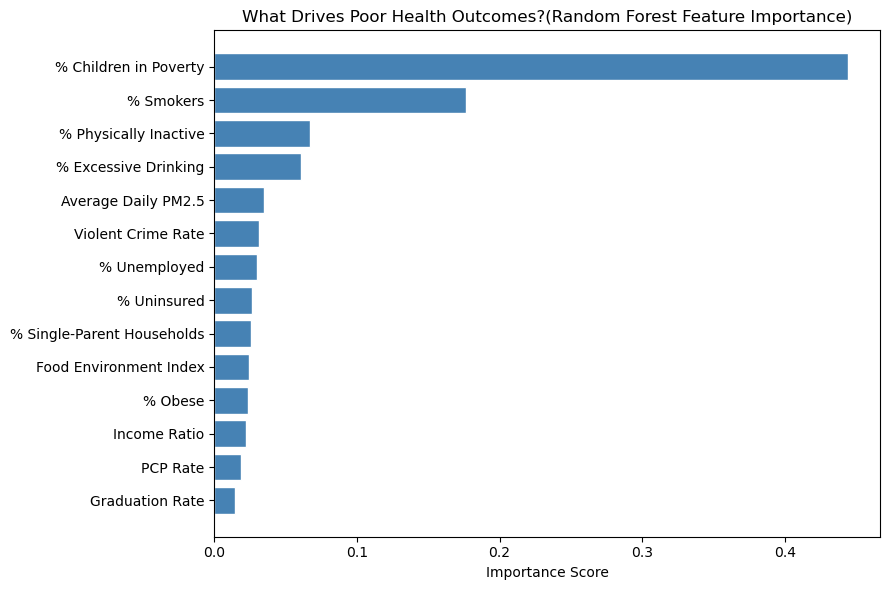

Top 5 drivers:
  1. % Children in Poverty: 0.4444
  2. % Smokers: 0.1766
  3. % Physically Inactive: 0.0673
  4. % Excessive Drinking: 0.0610
  5. Average Daily PM2.5: 0.0349


In [20]:
# Feature importance from Random Forest
importance = pd.Series(rf.feature_importances_, index=FEATURES)
importance = importance.sort_values(ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(importance.index, importance.values, color='steelblue', edgecolor='white')
plt.xlabel('Importance Score')
plt.title('What Drives Poor Health Outcomes?(Random Forest Feature Importance)')
plt.tight_layout()
plt.show()

print("Top 5 drivers:")
for i, (feat, val) in enumerate(importance.sort_values(ascending=False).head(5).items(), 1):
    print(f"  {i}. {feat}: {val:.4f}")

## 14. Summary

In [21]:
print("=" * 55)
print("  FINAL SUMMARY")
print("=" * 55)
print(f"Counties analysed : {len(y):,}")
print(f"Features used     : {len(FEATURES)}")
print("Model Results (Test Set):")
print(results.round(4).to_string(index=False))

top5 = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False).head(5)
print("Top 5 Drivers of Poor Health:")
for i, (f, v) in enumerate(top5.items(), 1):
    print(f"  {i}. {f}  ({v:.4f})")
print("=" * 55)

  FINAL SUMMARY
Counties analysed : 2,961
Features used     : 14
Model Results (Test Set):
            Model  Test RMSE  Test R2
    Random Forest  1348.3893   0.6911
Gradient Boosting  1397.3051   0.6682
            Ridge  1470.2301   0.6327
            Lasso  1473.4017   0.6311
              OLS  1474.4645   0.6306
Top 5 Drivers of Poor Health:
  1. % Children in Poverty  (0.4444)
  2. % Smokers  (0.1766)
  3. % Physically Inactive  (0.0673)
  4. % Excessive Drinking  (0.0610)
  5. Average Daily PM2.5  (0.0349)
